## 画像マスの抽出

In [171]:
import cv2
filename = "../data/level1/sample.jpg"
img = cv2.imread(filename, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("FaileRd to load image: {:s}".format(filename))

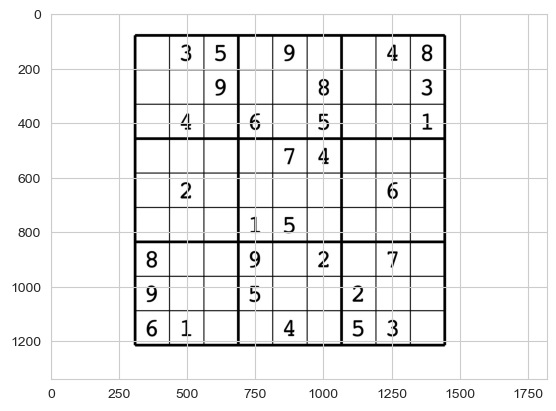

In [172]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [173]:
import cv2
import numpy as np

# 二値データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9 
stepy = h // 9
trim_size_x = stepx // 8
trim_size_y = stepy // 8
empty_threshold = 100
for i in range(9):
    for j in range(9):
        cell = img[y + i*stepy + trim_size_y : y + (i+1)*stepy - trim_size_y,
               x + j*stepx + trim_size_x : x + (j+1)*stepx - trim_size_x]
        resized_cell = cv2.resize(cell, (28, 28))
        gray_cell = cv2.cvtColor(resized_cell, cv2.COLOR_BGR2GRAY)
        normalized_cell = gray_cell / 255.0
        input_data = normalized_cell.reshape((28, 28, 1))  # モデルの入力形状に合わせてreshapeすること。
        cell_images.append(input_data)

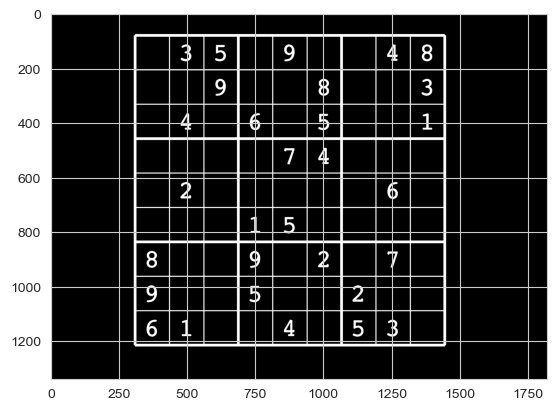

In [174]:
plt.imshow(thresh, cmap="gray")
plt.show()

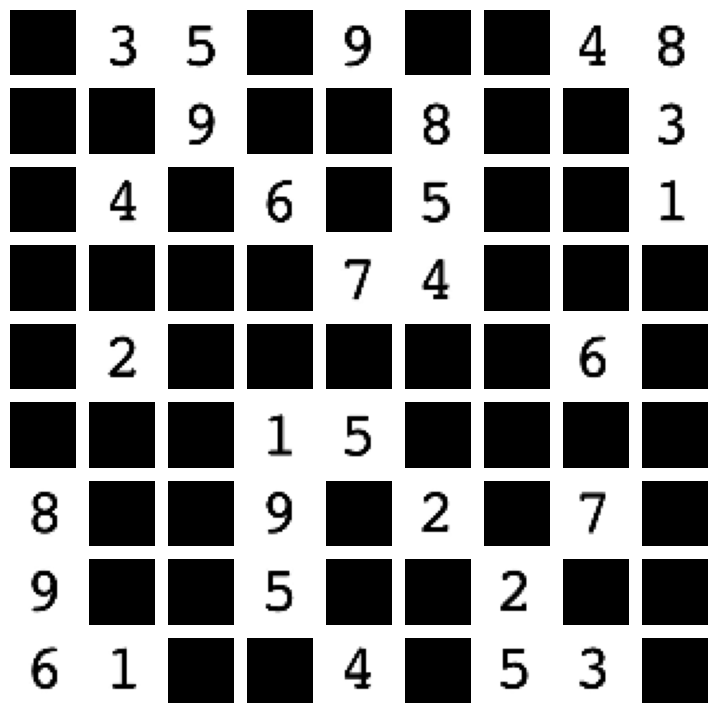

In [175]:
import matplotlib.pyplot as plt

## 抽出結果の可視化

# 9x9のグリッドを作り、各セルに画像をプロット
fig, axs = plt.subplots(9, 9, figsize=(9, 9))

# グリッドをフラットにしてイテレーションを行いやすくする
axs = axs.flatten()

# 各軸（ax）について画像をプロット
for ax, cell in zip(axs, cell_images):
    ax.imshow(cell, cmap="gray") # BGRからRGBへ変換
    ax.axis('off')  # 軸の情報をオフにする

plt.show()


## 数字の学習

In [176]:
# データ読み込み
import numpy as np
from sklearn import svm
photos = np.load('../data/samples/28px_10_new.npz')
x = photos['x']/255
y = photos['y']
print(x.shape)
print(y.shape)

# SVMで学習
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=1)
clf = svm.SVC()
clf.fit(X_train, y_train)

(1442, 784)
(1442,)


SVC()

In [177]:
from sklearn import metrics

# 予測の実行
predicted = clf.predict(X_test)
print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.84      0.91        38
           2       0.97      1.00      0.98        29
           3       0.90      0.96      0.93        28
           4       0.86      0.97      0.91        33
           5       1.00      0.90      0.95        30
           6       0.84      0.90      0.87        30
           7       0.88      0.97      0.93        38
           8       1.00      0.83      0.91        30
           9       0.90      0.93      0.92        29

    accuracy                           0.92       289
   macro avg       0.94      0.93      0.93       289
weighted avg       0.93      0.92      0.92       289


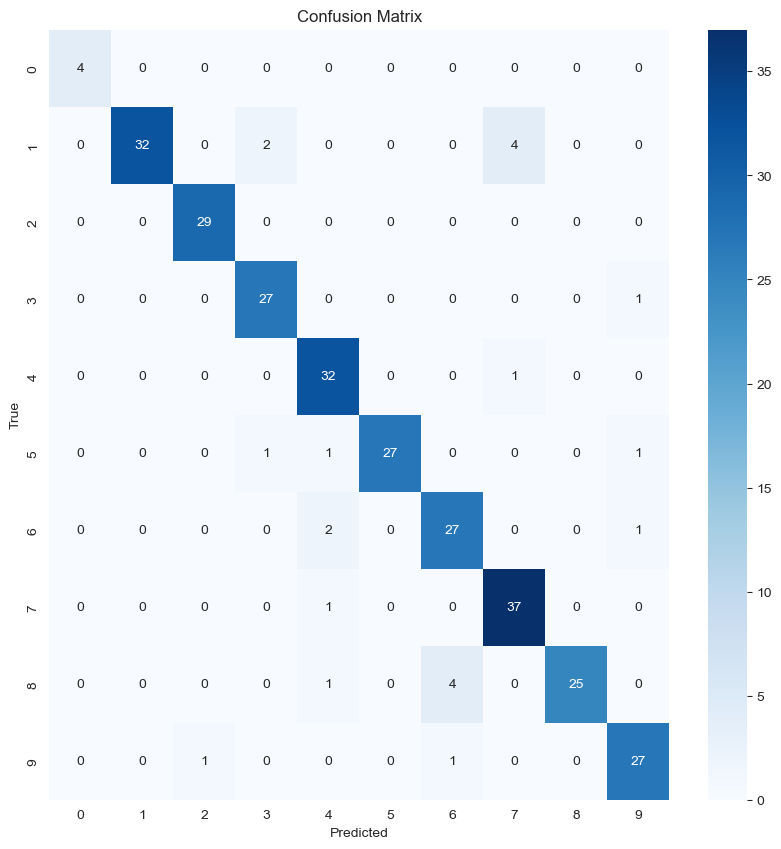

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

# 混同行列の可視化
conf_mat = metrics.confusion_matrix(y_test, predicted)
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [199]:
# モデルの保存
import pickle
serials = pickle.dumps(clf)
with open("../rbf_svm.pickle", "wb") as f:
    f.write(serials)

In [200]:
# 再読み込みとテスト
clf2 = None
with open("../rbf_svm.pickle", "rb") as f:
    clf2 = pickle.loads(f.read())

acc_test = clf2.score(X_test, y_test)
print("CV: acc(test)={:.2f}%".format(acc_test))

CV: acc(test)=0.92%


# 数字予測

In [179]:
# [追加] np.arrayに変換してモデル入力用データとする
model_input = np.array(cell_images)

# モデル入力を2次元に変換
model_input_2d = model_input.reshape(model_input.shape[0], -1)
# 予測
predicted = clf.predict(model_input_2d) 


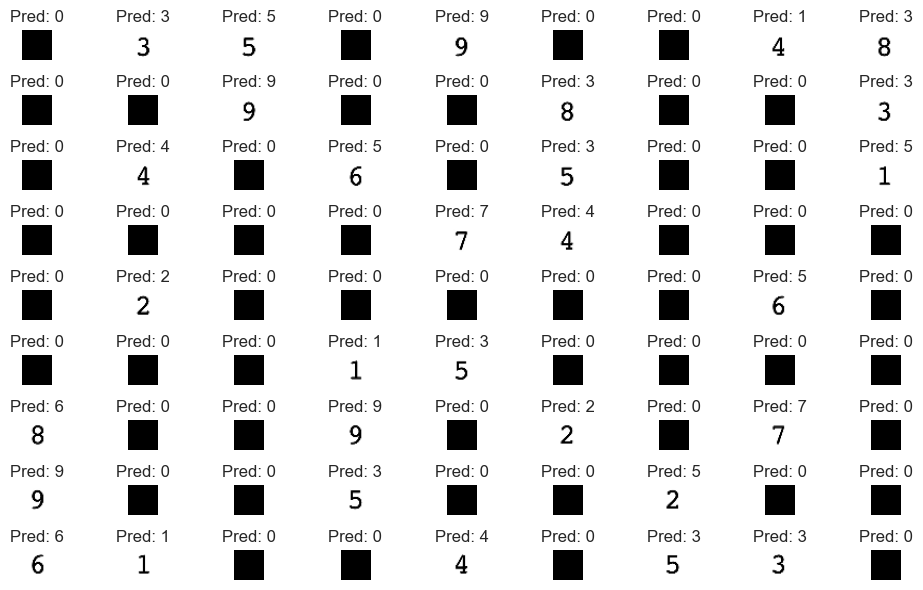

In [180]:
# 画像と予測結果を並べて表示します

# 行と列の数を設定
n_rows = 9
n_cols = 9

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))

# サブプロットを行と列にわたってループ
for i in range(n_rows):
    for j in range(n_cols):
        idx = i * n_cols + j  # インデックスを計算
        ax = axes[i, j]  # 現在のサブプロットを取得

        # インデックスが画像の数以上になったら終了
        if idx >= len(cell_images):
            break

        ax.imshow(cell_images[idx], cmap='gray')
        ax.set_title(f'Pred: {predicted[idx]}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [181]:
import numpy as np
filename = "../data/level1/sample.txt"
correct_labels = correct_labels = np.loadtxt(filename, dtype=int)
correct_labels_flat = correct_labels.flatten()

# Accuracyを計算して表示
accuracy = metrics.accuracy_score(correct_labels_flat, predicted)
print(f"Accuracy: {accuracy:.2f}")

print(metrics.classification_report(correct_labels_flat, predicted))

Accuracy: 0.85
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       0.67      0.67      0.67         3
           2       1.00      0.67      0.80         3
           3       0.33      1.00      0.50         3
           4       1.00      0.75      0.86         4
           5       0.20      0.20      0.20         5
           6       0.50      0.33      0.40         3
           7       1.00      1.00      1.00         2
           8       0.00      0.00      0.00         3
           9       1.00      1.00      1.00         4

    accuracy                           0.85        81
   macro avg       0.67      0.66      0.64        81
weighted avg       0.86      0.85      0.85        81


/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r